# M2.Ex1: Advertising Revenue

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [19]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

/home/mona/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Advertising Dataset

The Advertising Dataset is a fundamental resource in statistical learning and regression analysis. It is primarily known for its use in the first chapter of the seminal textbook "An Introduction to Statistical Learning" (ISLR) by Gareth James, Daniela Witten, Trevor Hastie, and Robert Tibshirani.

The dataset is used to illustrate the relationship between advertising budgets across different media and the resulting product sales.

- Features: `3` numerical
- Target: `sales` of the product (in thousands of units).
- Size: `200` samples.
- Source: [Advertising Dataset](https://www.statlearning.com/s/Advertising.csv)

### Step 1. Load the data

In [8]:
df=  pd.read_csv("/home/mona/Downloads/SAD/AAI/content/datasets/advertising.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


### Step 2.a Assign variables `X` to the features and `y` to the target

In [9]:
X= df[['TV','Radio','Newspaper']]
y= df['Sales']

### Step 2.b print the type of each

In [10]:
X.dtypes

TV           float64
Radio        float64
Newspaper    float64
dtype: object

In [11]:
y.dtype

dtype('float64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

the targer is numerical because continuous measurement of money/volume.

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [12]:
X.shape[0]


200

In [13]:
y.shape[0]

200

In [14]:
X.shape[1]

3

### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [15]:
X.describe()

,TV,Radio,Newspaper
count,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000
std,85.854236,14.846809,21.778621
min,0.700000,0.000000,0.300000
25%,74.375000,9.975000,12.750000
50%,149.750000,22.900000,25.750000
75%,218.825000,36.525000,45.100000
max,296.400000,49.600000,114.000000


In [16]:
X.median()

TV           149.75
Radio         22.90
Newspaper     25.75
dtype: float64

### Step 5. How much difference do you see in the scale of each feature? (calculate the featre-wise range differences)

In [17]:
ranges = X[['TV', 'Radio', 'Newspaper']].max() - X[['TV', 'Radio', 'Newspaper']].min()
ranges

TV           295.7
Radio         49.6
Newspaper    113.7
dtype: float64

### Step 6.a Plot each of the features vs the target

Hint use this: `sns.pairplot()`

Text(0, 0.5, 'Budget Amount ($)')

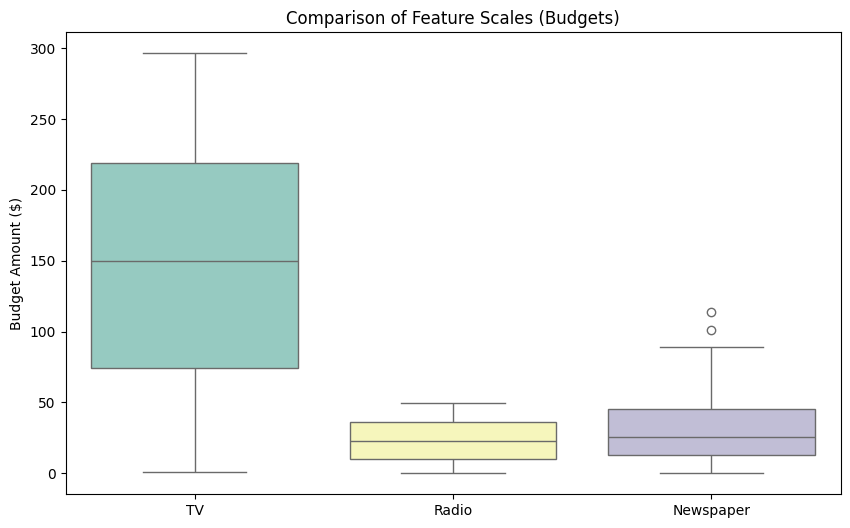

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['TV', 'Radio', 'Newspaper']], palette="Set3")

plt.title('Comparison of Feature Scales (Budgets)')
plt.ylabel('Budget Amount ($)')

### Step 6.b What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=TV` and `y=Sales`
2. `x=Radio` and `y=Sales`
3. `x=Newspaper` and `y=Sales`

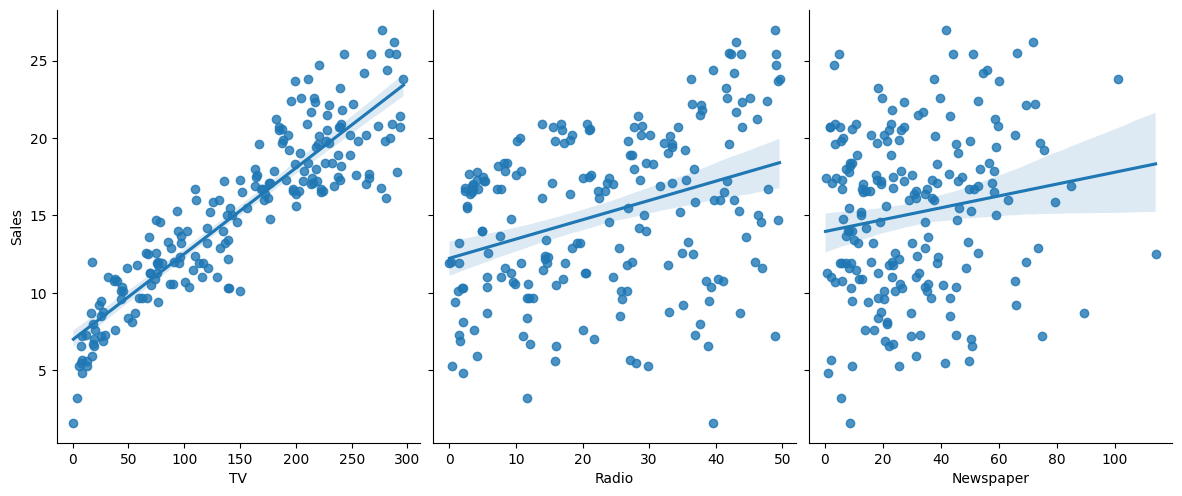

In [21]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=5, aspect=0.8, kind='reg')
plt.show()

- TV and Sales: A strong increasing relationship where higher TV spend consistently and reliably drives sales growth.

- Radio and Sales: A moderate increasing relationship where higher spend generally raises sales, though with less predictability than TV.

- Newspaper and Sales: Little to no relationship, as changes in newspaper spend show no consistent or clear impact on sales performance.

### Step 7. Define the pipeline with pre-processing steps

Make a Pipeline of three sequential steps:

1. transformer: `SimpleImputer` (to fill in missing values)
2. transformer: `StandardScaler` (to scale numerical features)
3. predictor: `LinearRegression` (to model the relationship)

In [ ]:
from sklearn.pipeline import Pipeline





In [ ]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

### Step 9.a Fit the pipeline on the training set

In [ ]:
pipe.fit(X_train, y_train)

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

### Step 9.c how much spending on TV `$1,000` more, factor into Sales?

### Step 9.d if we take `$5,000` away from Newspaper and put it in Radio how much difference does that make into Sales?

### Step 9.e if we spend nothing at all on advertising, how much do we estimate our Sales to be?

### Step 10. Evaluate the pipeline on the test set

In [ ]:
score = pipe.score(X_test, y_test)

### Step 11. Define a `LinearRegression` model without the pre-processing steps, and compare it's score with the pipeline. Which one is better?